In [1]:
import pandas as pd

# Load your existing dataframes
# If you're continuing in the same notebook, skip these two lines
crypto_prices = pd.read_excel("crypto_daily_prices.xlsx", index_col="Date", parse_dates=True)
equity_prices = pd.read_excel("equity_daily_prices.xlsx", index_col="Date", parse_dates=True)

# Calculate daily returns
crypto_returns = crypto_prices.pct_change().dropna()
equity_returns = equity_prices.pct_change().dropna()

# Split into pre and post ETF periods
pre_start  = "2021-01-01"
pre_end    = "2023-12-31"
post_start = "2024-01-01"
post_end   = "2026-01-01"

# Crypto splits
crypto_returns_pre  = crypto_returns[pre_start:pre_end]
crypto_returns_post = crypto_returns[post_start:post_end]

# Equity splits
equity_returns_pre  = equity_returns[pre_start:pre_end]
equity_returns_post = equity_returns[post_start:post_end]

# Preview
print("Crypto returns — full:")
print(crypto_returns.shape)
print(crypto_returns.head())

print("\nEquity returns — full:")
print(equity_returns.shape)
print(equity_returns.head())

print(f"\nCrypto pre-ETF:  {crypto_returns_pre.shape}")
print(f"Crypto post-ETF: {crypto_returns_post.shape}")
print(f"Equity pre-ETF:  {equity_returns_pre.shape}")
print(f"Equity post-ETF: {equity_returns_post.shape}")

# Save all to excel
with pd.ExcelWriter("returns_data.xlsx") as writer:
    crypto_returns.to_excel(writer, sheet_name="Crypto Returns Full")
    equity_returns.to_excel(writer, sheet_name="Equity Returns Full")
    crypto_returns_pre.to_excel(writer, sheet_name="Crypto Pre ETF")
    crypto_returns_post.to_excel(writer, sheet_name="Crypto Post ETF")
    equity_returns_pre.to_excel(writer, sheet_name="Equity Pre ETF")
    equity_returns_post.to_excel(writer, sheet_name="Equity Post ETF")

print("\nSaved to returns_data.xlsx")

/var/folders/q9/_jmy2jy533vdw8fbp9d85t5r0000gn/T/ipykernel_5752/4018234937.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crypto_returns = crypto_prices.pct_change().dropna()


Crypto returns — full:
(1825, 20)
             Bitcoin  Ethereum       XRP  Litecoin  Polkadot  Bitcoin Cash  \
Date                                                                         
2021-01-02  0.093726  0.060473 -0.066496  0.084881  0.108588      0.036885   
2021-01-03  0.020380  0.259475  0.018917  0.169745  0.089528      0.189481   
2021-01-04 -0.024712  0.066350  0.047948 -0.033605 -0.056180     -0.032843   
2021-01-05  0.063197  0.057461 -0.041943  0.024466  0.024504      0.029003   
2021-01-06  0.083311  0.097369  0.106483  0.065716  0.040654      0.082703   

            Binance Coin   Cardano  Chainlink  Bitcoin SV   Stellar       EOS  \
Date                                                                            
2021-01-02      0.008880  0.011822   0.029276   -0.000162 -0.034650 -0.003420   
2021-01-03      0.076027  0.155403   0.117023    0.050900  0.067306  0.064204   
2021-01-04     -0.005410  0.096427  -0.005795   -0.022186  0.210793  0.005459   
2021-01-05    

Crypto Pre-ETF | 1 Week | XS Sharpe: -1.116 | TS Sharpe: -0.667
Crypto Pre-ETF | 1 Month | XS Sharpe: 0.484 | TS Sharpe: -0.485
Crypto Pre-ETF | 3 Months | XS Sharpe: -0.495 | TS Sharpe: -0.495
Crypto Post-ETF | 1 Week | XS Sharpe: -0.38 | TS Sharpe: 0.169
Crypto Post-ETF | 1 Month | XS Sharpe: 0.805 | TS Sharpe: 0.241
Crypto Post-ETF | 3 Months | XS Sharpe: 1.105 | TS Sharpe: 0.585
Equity Pre-ETF | 1 Week | XS Sharpe: 0.975 | TS Sharpe: 0.362
Equity Pre-ETF | 1 Month | XS Sharpe: 0.096 | TS Sharpe: 0.155
Equity Pre-ETF | 3 Months | XS Sharpe: 0.062 | TS Sharpe: -0.189
Equity Post-ETF | 1 Week | XS Sharpe: -0.286 | TS Sharpe: -0.158
Equity Post-ETF | 1 Month | XS Sharpe: -0.422 | TS Sharpe: -0.013
Equity Post-ETF | 3 Months | XS Sharpe: -0.129 | TS Sharpe: 0.16


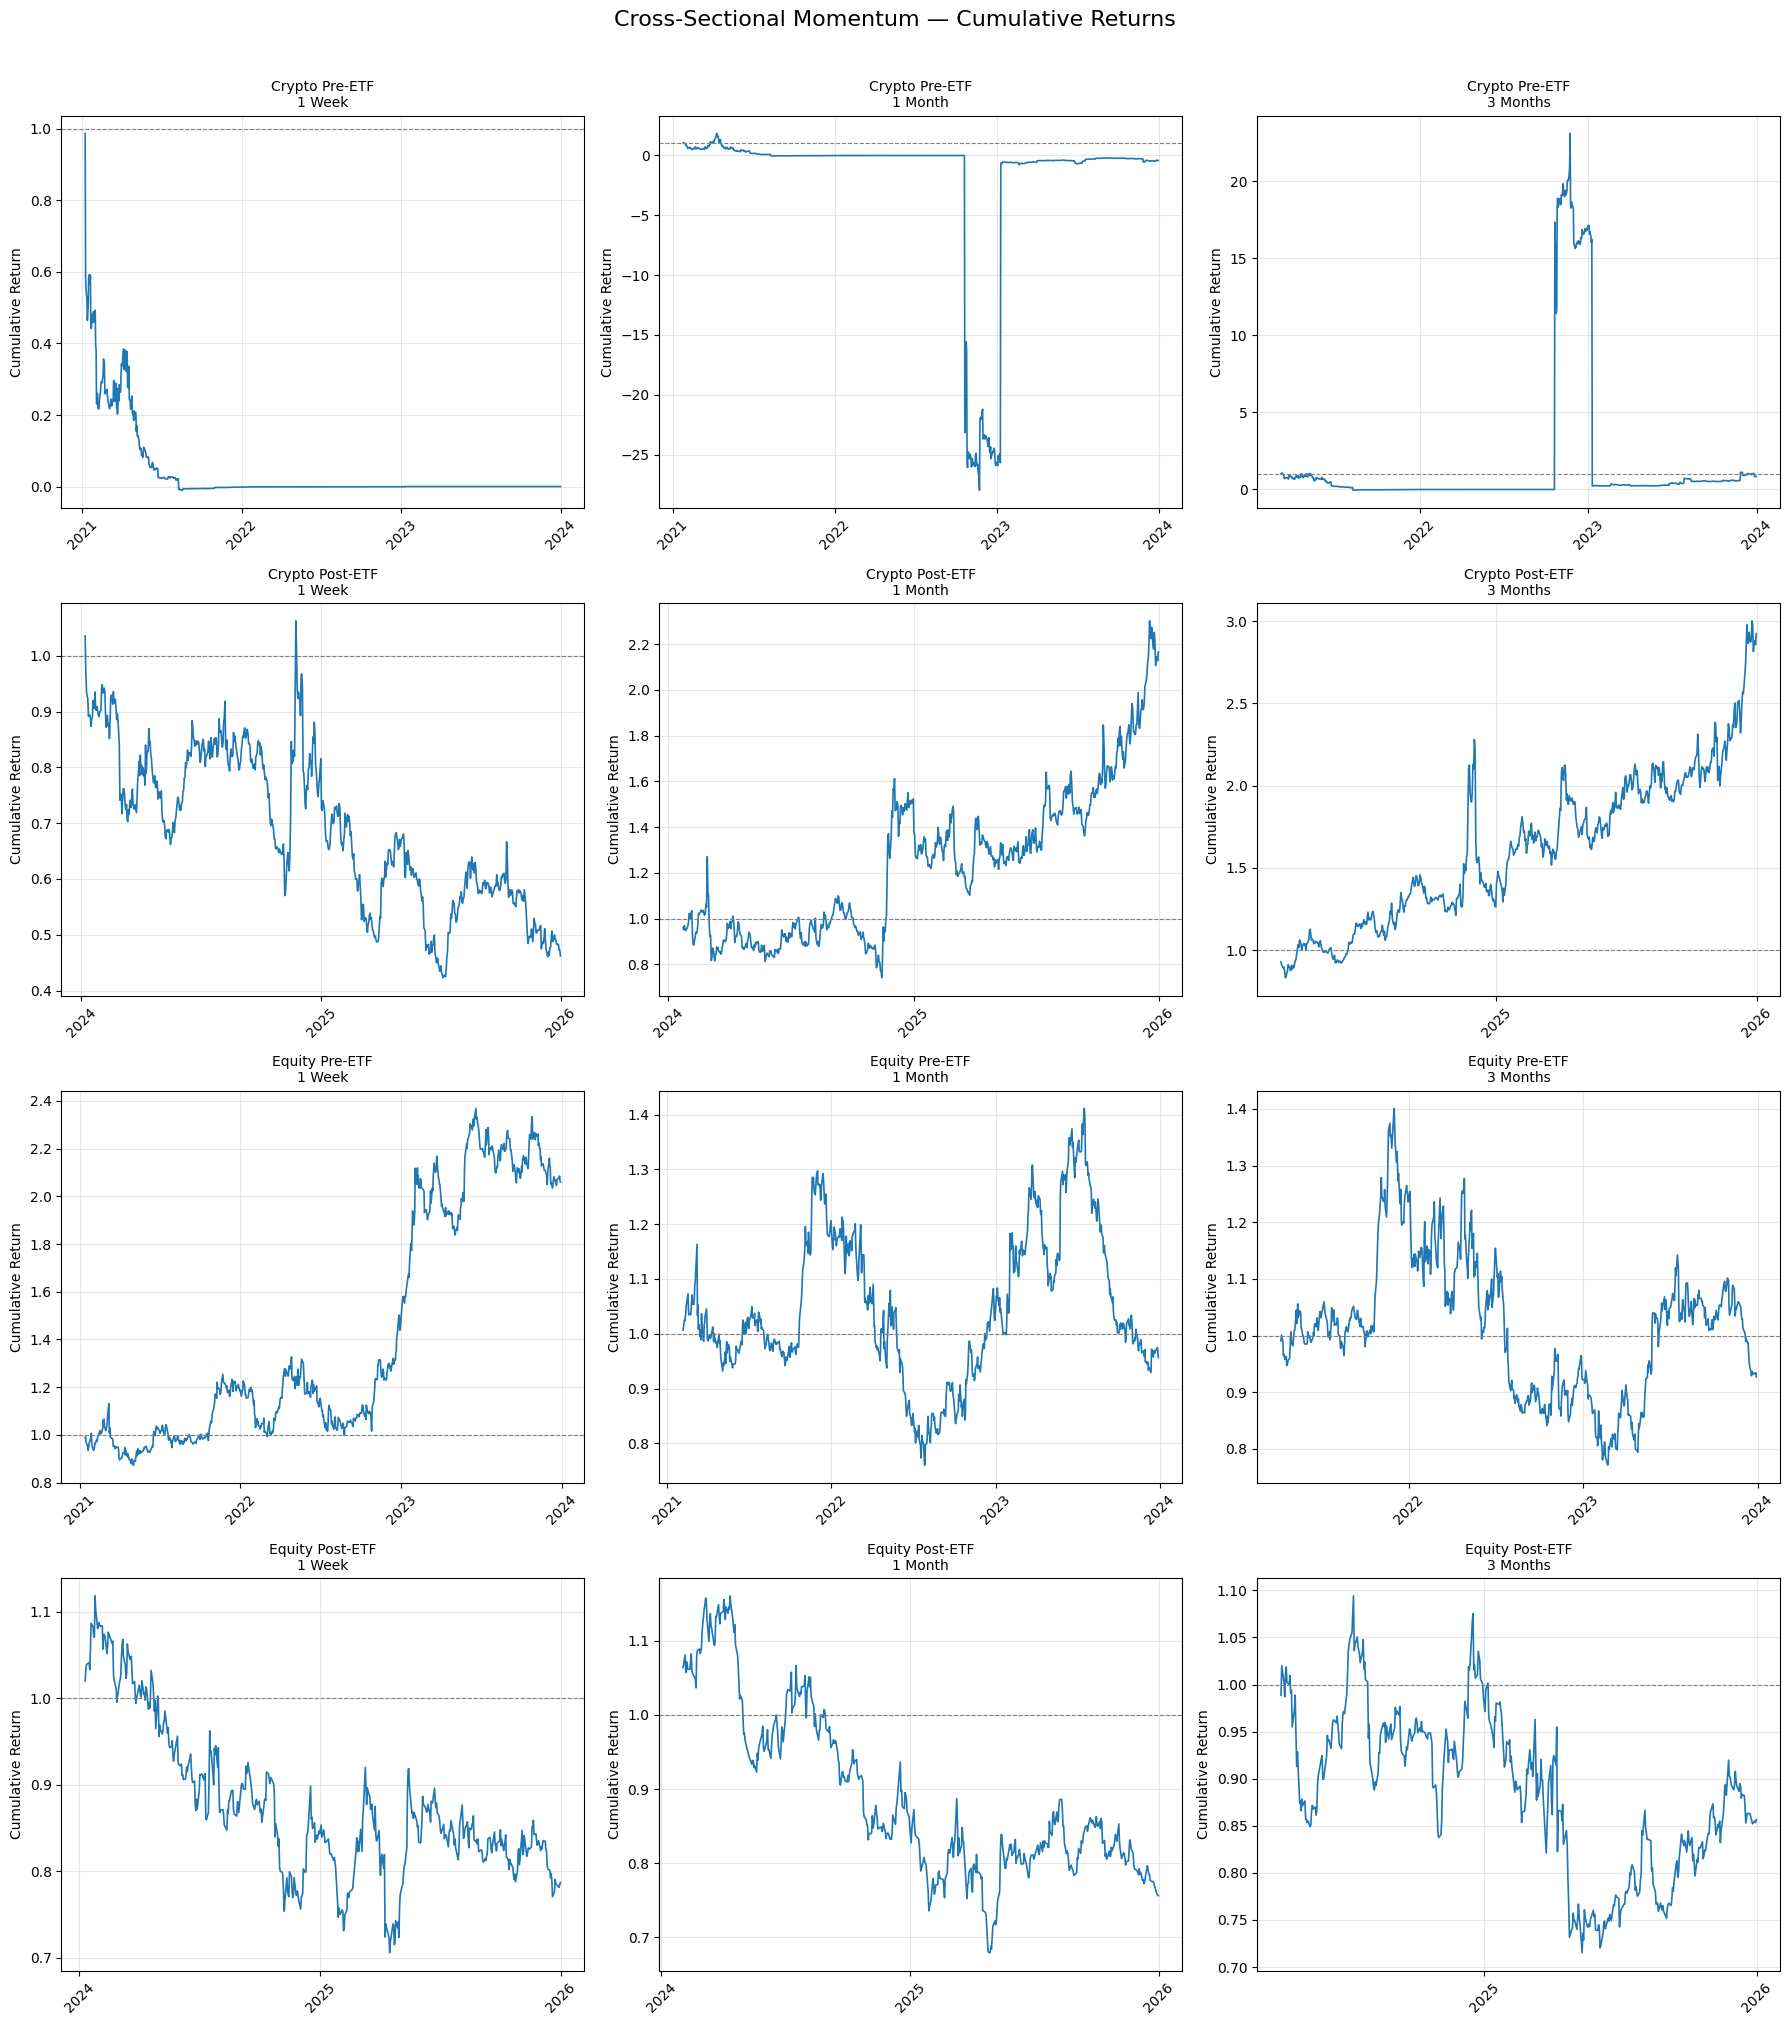

Saved xsmom_cumulative.png


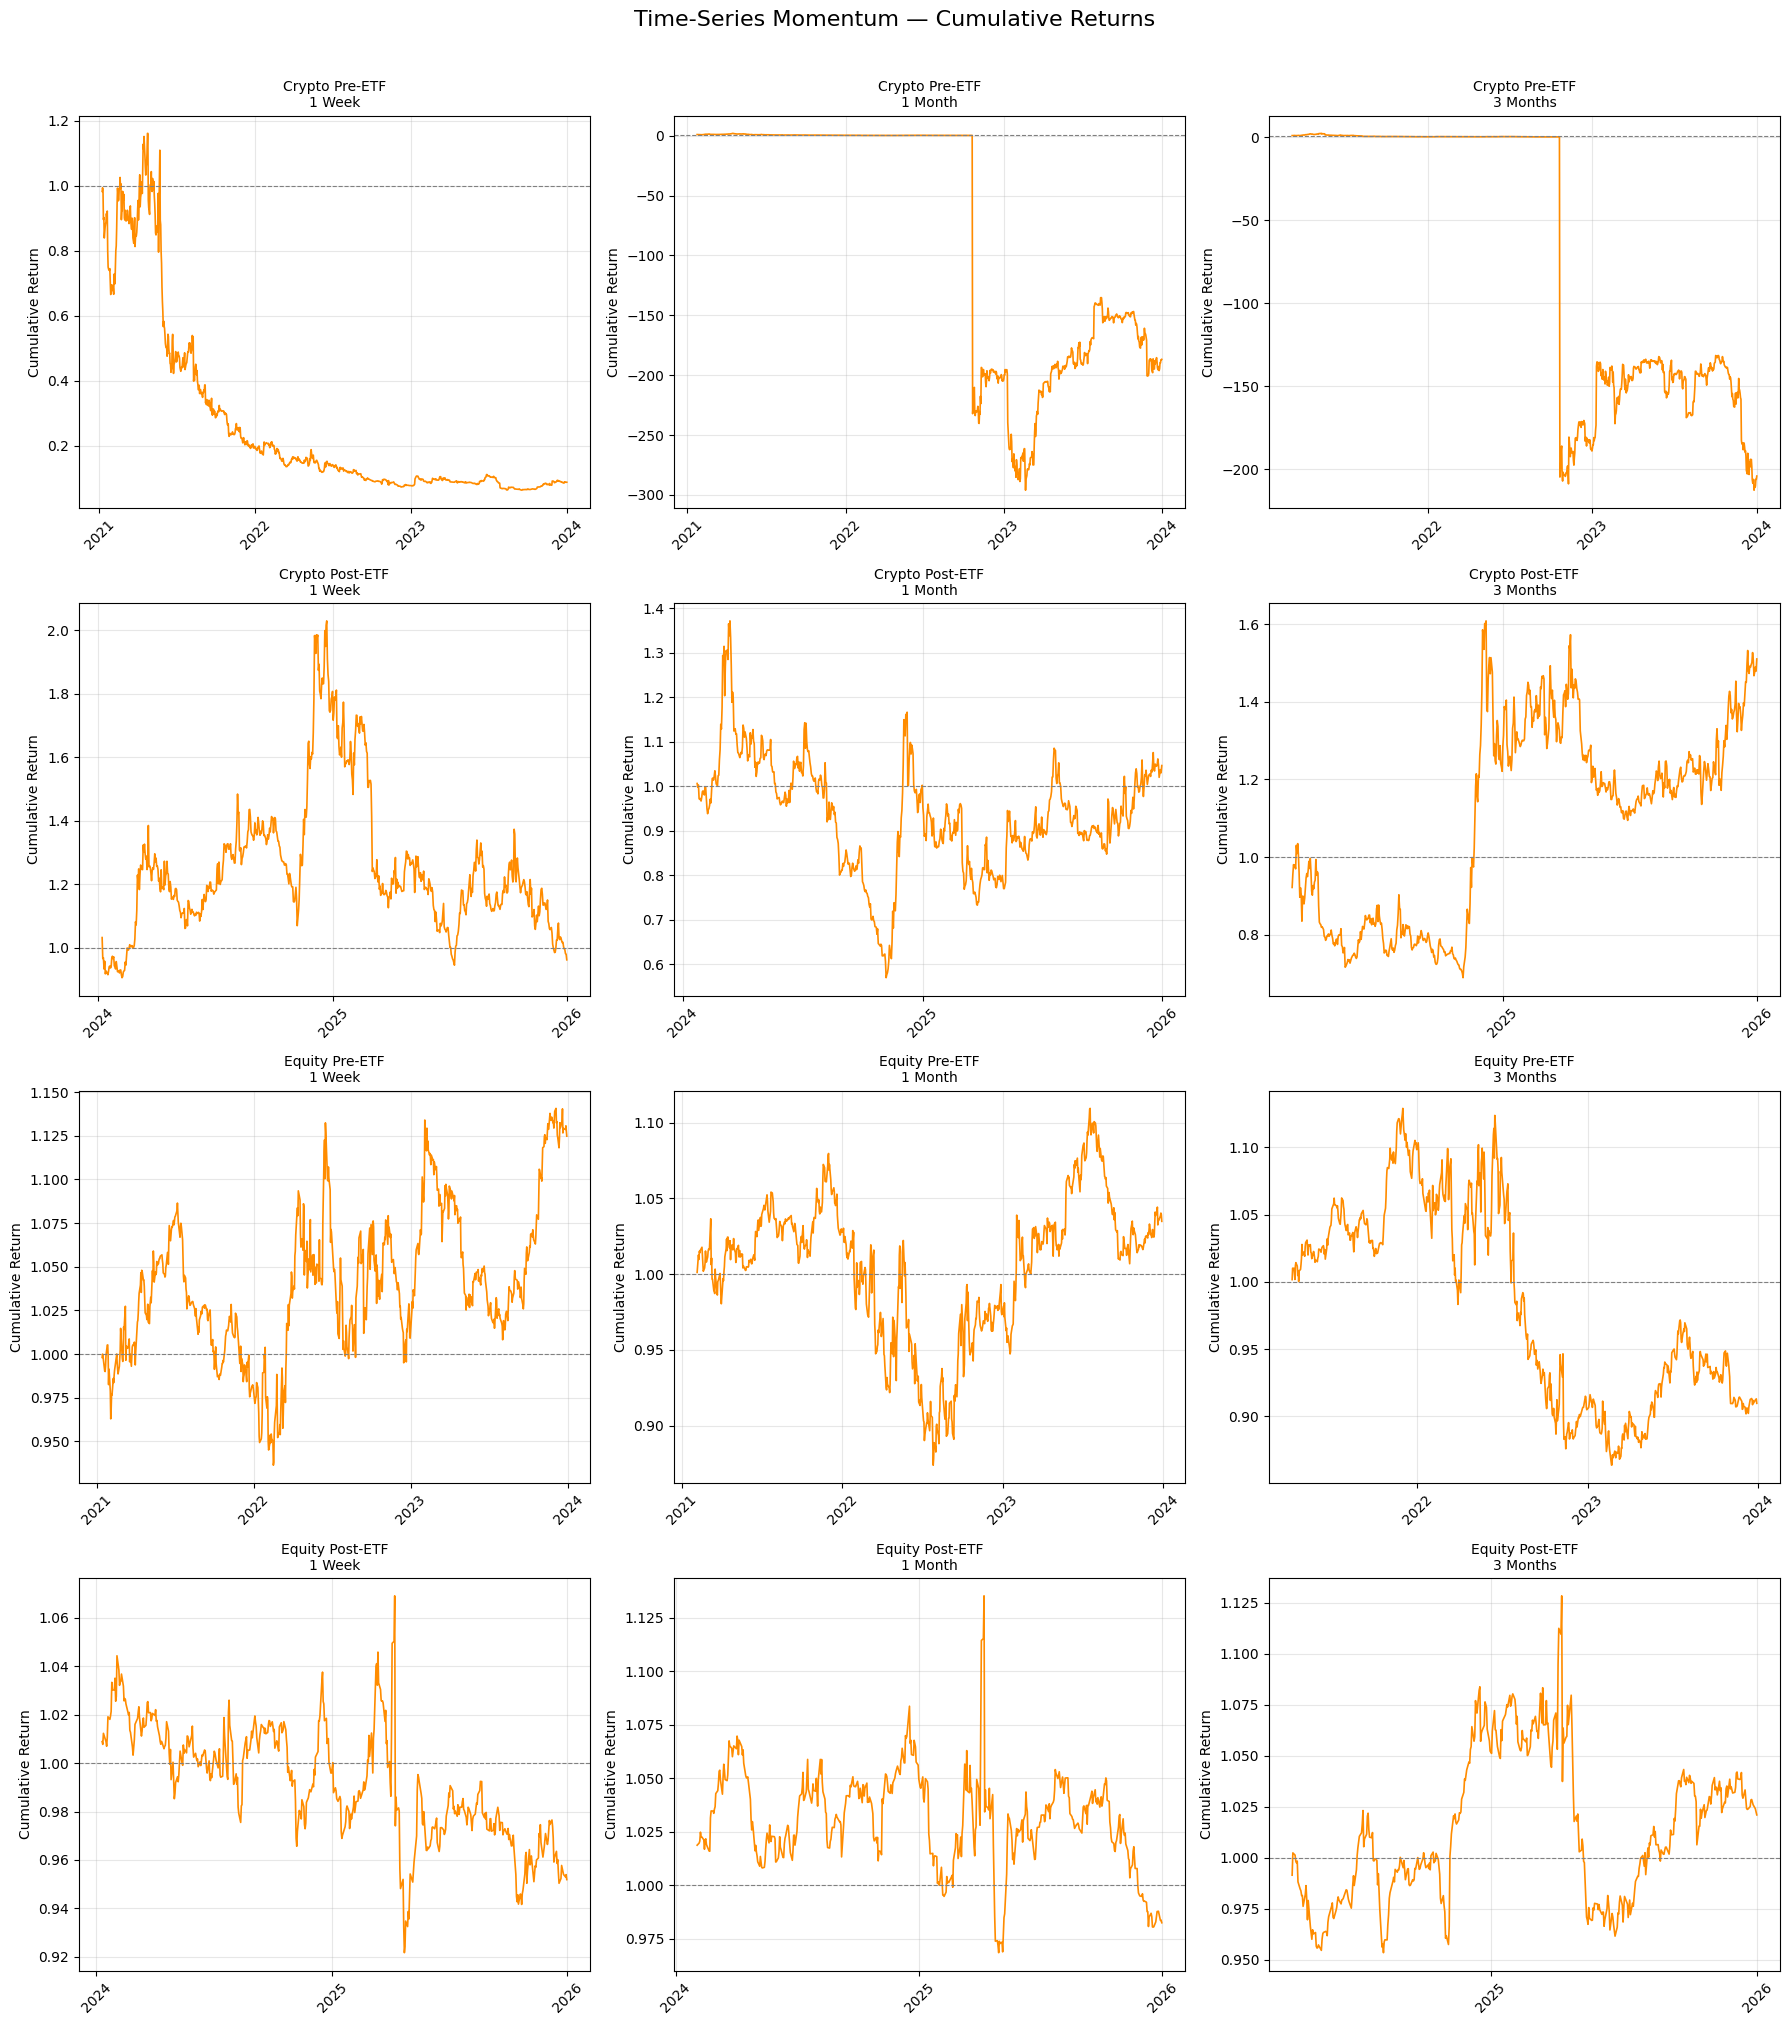

Saved tsmom_cumulative.png

── Sharpe Ratio Summary ──
        Dataset   Window  XS Sharpe  TS Sharpe
 Crypto Pre-ETF   1 Week     -1.116     -0.667
 Crypto Pre-ETF  1 Month      0.484     -0.485
 Crypto Pre-ETF 3 Months     -0.495     -0.495
Crypto Post-ETF   1 Week     -0.380      0.169
Crypto Post-ETF  1 Month      0.805      0.241
Crypto Post-ETF 3 Months      1.105      0.585
 Equity Pre-ETF   1 Week      0.975      0.362
 Equity Pre-ETF  1 Month      0.096      0.155
 Equity Pre-ETF 3 Months      0.062     -0.189
Equity Post-ETF   1 Week     -0.286     -0.158
Equity Post-ETF  1 Month     -0.422     -0.013
Equity Post-ETF 3 Months     -0.129      0.160

Saved momentum_sharpe_summary.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── lookback windows (trading days) ──────────────────────────────────────
windows = {
    "1 Week":   5,
    "1 Month":  21,
    "3 Months": 63
}

# ── helper: cross-sectional momentum ─────────────────────────────────────
def cross_sectional_momentum(returns_df, lookback, top_pct=0.2):
    """
    Each day:
      1. Compute past return over lookback window
      2. Rank assets — long top 20%, short bottom 20%
      3. Record equal-weighted portfolio return next day
    """
    n = len(returns_df.columns)
    n_assets = max(1, int(n * top_pct))
    portfolio_returns = []

    prices = (1 + returns_df).cumprod()  # reconstruct price index

    for i in range(lookback, len(returns_df) - 1):
        # past return over lookback window
        past_returns = prices.iloc[i] / prices.iloc[i - lookback] - 1

        ranked = past_returns.rank()
        long_assets  = ranked.nlargest(n_assets).index
        short_assets = ranked.nsmallest(n_assets).index

        next_day = returns_df.iloc[i + 1]
        port_return = next_day[long_assets].mean() - next_day[short_assets].mean()
        portfolio_returns.append({
            "Date": returns_df.index[i + 1],
            "Return": port_return
        })

    result = pd.DataFrame(portfolio_returns).set_index("Date")
    result["Cumulative"] = (1 + result["Return"]).cumprod()
    return result

# ── helper: time-series momentum ─────────────────────────────────────────
def time_series_momentum(returns_df, lookback):
    """
    Each day:
      1. For each asset, check if past return is positive or negative
      2. Long if positive, short if negative
      3. Record equal-weighted portfolio return next day
    """
    portfolio_returns = []
    prices = (1 + returns_df).cumprod()

    for i in range(lookback, len(returns_df) - 1):
        past_returns = prices.iloc[i] / prices.iloc[i - lookback] - 1
        signals = np.sign(past_returns)  # +1 or -1

        next_day = returns_df.iloc[i + 1]
        port_return = (signals * next_day).mean()
        portfolio_returns.append({
            "Date": returns_df.index[i + 1],
            "Return": port_return
        })

    result = pd.DataFrame(portfolio_returns).set_index("Date")
    result["Cumulative"] = (1 + result["Return"]).cumprod()
    return result

# ── helper: Sharpe ratio ──────────────────────────────────────────────────
def sharpe(returns_series, periods_per_year=252):
    mean = returns_series.mean() * periods_per_year
    std  = returns_series.std() * np.sqrt(periods_per_year)
    return round(mean / std, 3) if std != 0 else np.nan

# ── run all combinations ──────────────────────────────────────────────────
datasets = {
    "Crypto Pre-ETF":  crypto_returns_pre,
    "Crypto Post-ETF": crypto_returns_post,
    "Equity Pre-ETF":  equity_returns_pre,
    "Equity Post-ETF": equity_returns_post
}

xsmom_results = {}  # cross-sectional
tsmom_results = {}  # time-series

for label, df in datasets.items():
    xsmom_results[label] = {}
    tsmom_results[label] = {}
    for wname, wdays in windows.items():
        xsmom_results[label][wname] = cross_sectional_momentum(df, wdays)
        tsmom_results[label][wname] = time_series_momentum(df, wdays)
        print(f"{label} | {wname} | "
              f"XS Sharpe: {sharpe(xsmom_results[label][wname]['Return'])} | "
              f"TS Sharpe: {sharpe(tsmom_results[label][wname]['Return'])}")

# ── plotting ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle("Cross-Sectional Momentum — Cumulative Returns", fontsize=16, y=1.01)

for row_idx, (label, window_dict) in enumerate(xsmom_results.items()):
    for col_idx, (wname, result) in enumerate(window_dict.items()):
        ax = axes[row_idx][col_idx]
        ax.plot(result.index, result["Cumulative"], linewidth=1.2)
        ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(f"{label}\n{wname}", fontsize=10)
        ax.set_ylabel("Cumulative Return")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("xsmom_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved xsmom_cumulative.png")

# ── time series momentum plot ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle("Time-Series Momentum — Cumulative Returns", fontsize=16, y=1.01)

for row_idx, (label, window_dict) in enumerate(tsmom_results.items()):
    for col_idx, (wname, result) in enumerate(window_dict.items()):
        ax = axes[row_idx][col_idx]
        ax.plot(result.index, result["Cumulative"], linewidth=1.2, color="darkorange")
        ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(f"{label}\n{wname}", fontsize=10)
        ax.set_ylabel("Cumulative Return")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("tsmom_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved tsmom_cumulative.png")

# ── Sharpe summary table ──────────────────────────────────────────────────
sharpe_rows = []
for label in datasets.keys():
    for wname in windows.keys():
        sharpe_rows.append({
            "Dataset":    label,
            "Window":     wname,
            "XS Sharpe":  sharpe(xsmom_results[label][wname]["Return"]),
            "TS Sharpe":  sharpe(tsmom_results[label][wname]["Return"])
        })

sharpe_df = pd.DataFrame(sharpe_rows)
print("\n── Sharpe Ratio Summary ──")
print(sharpe_df.to_string(index=False))

sharpe_df.to_excel("momentum_sharpe_summary.xlsx", index=False)
print("\nSaved momentum_sharpe_summary.xlsx")

## After the discover of when the news hit the market. We Split the data with new dates. Pre ETF annoucement, and post ETF annoucement

In [6]:

# Load prices
crypto_prices = pd.read_excel("crypto_daily_prices.xlsx", index_col="Date", parse_dates=True)
equity_prices = pd.read_excel("equity_daily_prices.xlsx", index_col="Date", parse_dates=True)

# Calculate daily returns
crypto_returns = crypto_prices.pct_change().dropna()
equity_returns = equity_prices.pct_change().dropna()

# New cutoff — ETF news date June 15 2023
pre_start  = "2021-01-01"
pre_end    = "2023-06-15"
post_start = "2023-06-16"
post_end   = "2026-01-01"

# Crypto splits
crypto_returns_pre  = crypto_returns[pre_start:pre_end]
crypto_returns_post = crypto_returns[post_start:post_end]

# Equity splits
equity_returns_pre  = equity_returns[pre_start:pre_end]
equity_returns_post = equity_returns[post_start:post_end]

# Preview
print("Crypto returns — full:")
print(crypto_returns.shape)
print(crypto_returns.head())

print("\nEquity returns — full:")
print(equity_returns.shape)
print(equity_returns.head())

print(f"\nCrypto pre-ETF:  {crypto_returns_pre.shape}")
print(f"Crypto post-ETF: {crypto_returns_post.shape}")
print(f"Equity pre-ETF:  {equity_returns_pre.shape}")
print(f"Equity post-ETF: {equity_returns_post.shape}")

# Save to new excel
with pd.ExcelWriter("returns_annoucement_adj.xlsx") as writer:
    crypto_returns.to_excel(writer, sheet_name="Crypto Returns Full")
    equity_returns.to_excel(writer, sheet_name="Equity Returns Full")
    crypto_returns_pre.to_excel(writer, sheet_name="Crypto Pre ETF")
    crypto_returns_post.to_excel(writer, sheet_name="Crypto Post ETF")
    equity_returns_pre.to_excel(writer, sheet_name="Equity Pre ETF")
    equity_returns_post.to_excel(writer, sheet_name="Equity Post ETF")

print("\nSaved to returns_annoucement_adj.xlsx")

/var/folders/q9/_jmy2jy533vdw8fbp9d85t5r0000gn/T/ipykernel_5752/2305073842.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crypto_returns = crypto_prices.pct_change().dropna()


Crypto returns — full:
(1825, 20)
             Bitcoin  Ethereum       XRP  Litecoin  Polkadot  Bitcoin Cash  \
Date                                                                         
2021-01-02  0.093726  0.060473 -0.066496  0.084881  0.108588      0.036885   
2021-01-03  0.020380  0.259475  0.018917  0.169745  0.089528      0.189481   
2021-01-04 -0.024712  0.066350  0.047948 -0.033605 -0.056180     -0.032843   
2021-01-05  0.063197  0.057461 -0.041943  0.024466  0.024504      0.029003   
2021-01-06  0.083311  0.097369  0.106483  0.065716  0.040654      0.082703   

            Binance Coin   Cardano  Chainlink  Bitcoin SV   Stellar       EOS  \
Date                                                                            
2021-01-02      0.008880  0.011822   0.029276   -0.000162 -0.034650 -0.003420   
2021-01-03      0.076027  0.155403   0.117023    0.050900  0.067306  0.064204   
2021-01-04     -0.005410  0.096427  -0.005795   -0.022186  0.210793  0.005459   
2021-01-05    

Crypto Pre-ETF | 1 Week | XS Sharpe: -1.483 | TS Sharpe: -0.773
Crypto Pre-ETF | 1 Month | XS Sharpe: 0.537 | TS Sharpe: -0.538
Crypto Pre-ETF | 3 Months | XS Sharpe: -0.551 | TS Sharpe: -0.551
Crypto Post-ETF | 1 Week | XS Sharpe: 0.115 | TS Sharpe: 0.139
Crypto Post-ETF | 1 Month | XS Sharpe: 0.385 | TS Sharpe: 0.224
Crypto Post-ETF | 3 Months | XS Sharpe: 0.734 | TS Sharpe: 0.743
Equity Pre-ETF | 1 Week | XS Sharpe: 1.259 | TS Sharpe: 0.208
Equity Pre-ETF | 1 Month | XS Sharpe: 0.559 | TS Sharpe: 0.284
Equity Pre-ETF | 3 Months | XS Sharpe: 0.221 | TS Sharpe: -0.12
Equity Post-ETF | 1 Week | XS Sharpe: -0.358 | TS Sharpe: 0.17
Equity Post-ETF | 1 Month | XS Sharpe: -0.822 | TS Sharpe: -0.174
Equity Post-ETF | 3 Months | XS Sharpe: 0.169 | TS Sharpe: 0.628


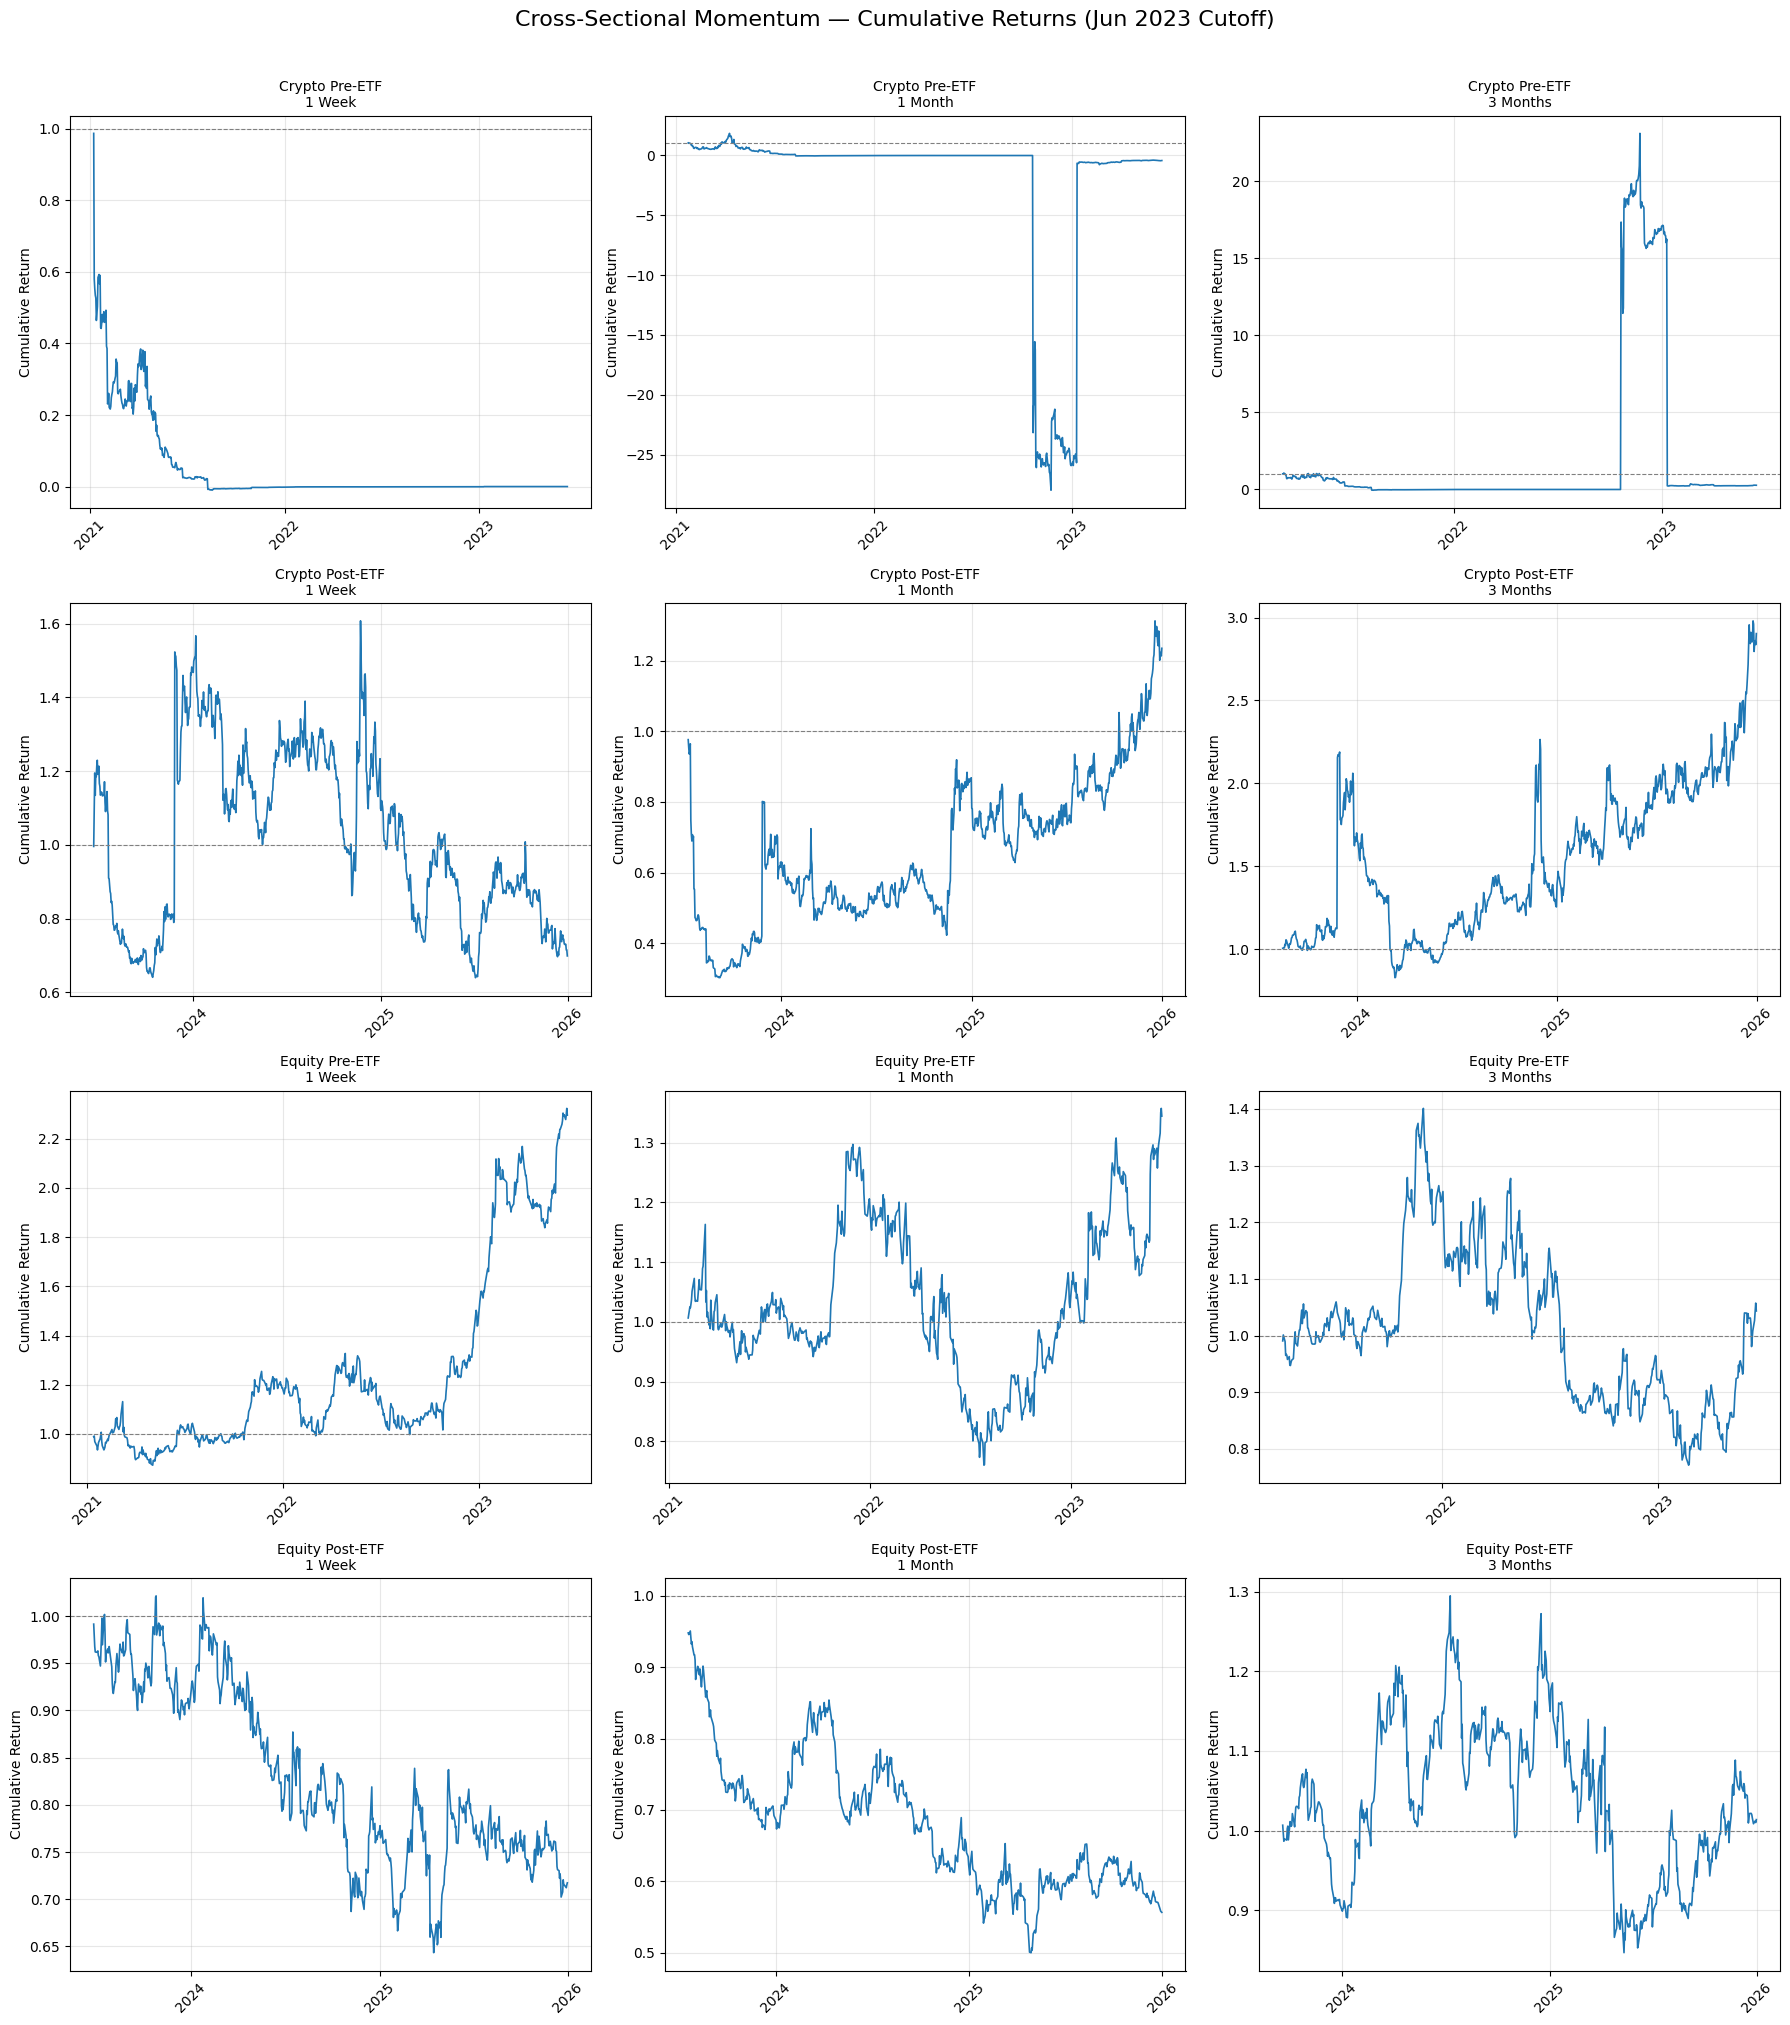

Saved xsmom_cumulative_jun2023_announcement.png


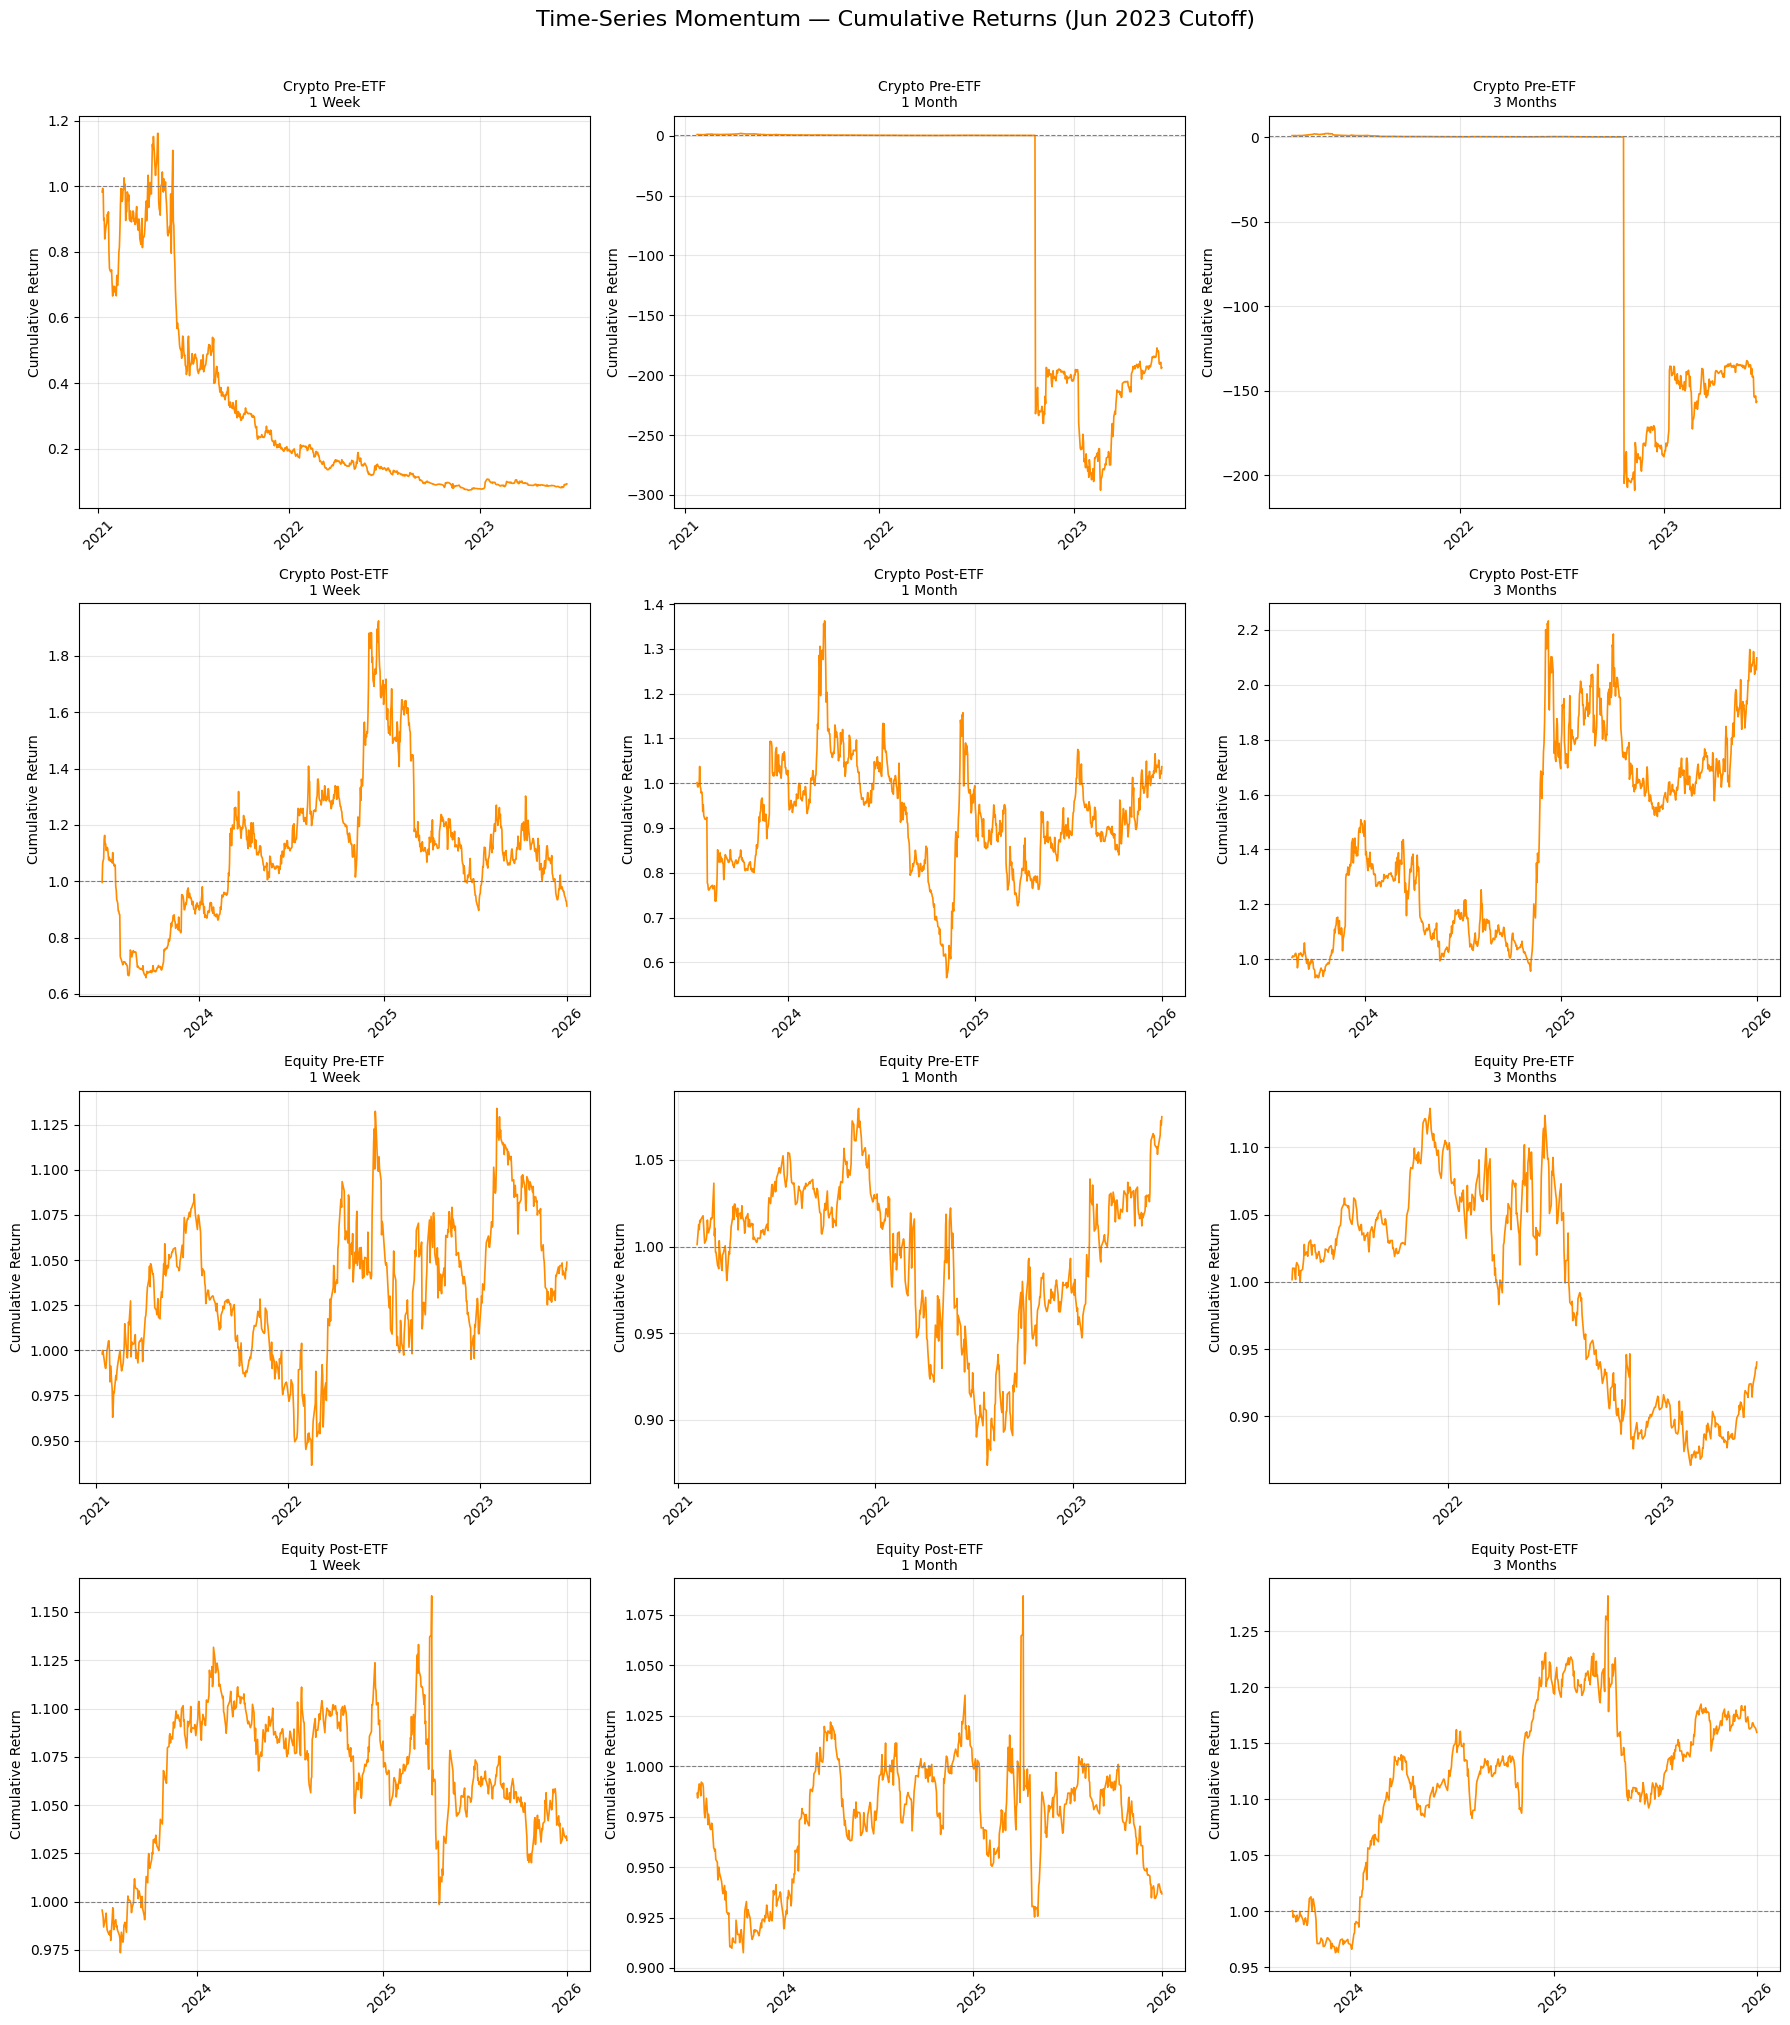

Saved tsmom_cumulative_jun2023_announcement.png

── Sharpe Ratio Summary (Jun 2023 Announcement Cutoff) ──
        Dataset   Window  XS Sharpe  TS Sharpe
 Crypto Pre-ETF   1 Week     -1.483     -0.773
 Crypto Pre-ETF  1 Month      0.537     -0.538
 Crypto Pre-ETF 3 Months     -0.551     -0.551
Crypto Post-ETF   1 Week      0.115      0.139
Crypto Post-ETF  1 Month      0.385      0.224
Crypto Post-ETF 3 Months      0.734      0.743
 Equity Pre-ETF   1 Week      1.259      0.208
 Equity Pre-ETF  1 Month      0.559      0.284
 Equity Pre-ETF 3 Months      0.221     -0.120
Equity Post-ETF   1 Week     -0.358      0.170
Equity Post-ETF  1 Month     -0.822     -0.174
Equity Post-ETF 3 Months      0.169      0.628

Saved momentum_sharpe_jun2023_announcement.xlsx


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── load data from new file ───────────────────────────────────────────────
crypto_returns_pre  = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Crypto Pre ETF",  index_col="Date", parse_dates=True)
crypto_returns_post = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Crypto Post ETF", index_col="Date", parse_dates=True)
equity_returns_pre  = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Equity Pre ETF",  index_col="Date", parse_dates=True)
equity_returns_post = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Equity Post ETF", index_col="Date", parse_dates=True)

# ── lookback windows (trading days) ──────────────────────────────────────
windows = {
    "1 Week":   5,
    "1 Month":  21,
    "3 Months": 63
}

# ── helper: cross-sectional momentum ─────────────────────────────────────
def cross_sectional_momentum(returns_df, lookback, top_pct=0.2):
    n = len(returns_df.columns)
    n_assets = max(1, int(n * top_pct))
    portfolio_returns = []
    prices = (1 + returns_df).cumprod()

    for i in range(lookback, len(returns_df) - 1):
        past_returns = prices.iloc[i] / prices.iloc[i - lookback] - 1
        ranked = past_returns.rank()
        long_assets  = ranked.nlargest(n_assets).index
        short_assets = ranked.nsmallest(n_assets).index
        next_day = returns_df.iloc[i + 1]
        port_return = next_day[long_assets].mean() - next_day[short_assets].mean()
        portfolio_returns.append({
            "Date": returns_df.index[i + 1],
            "Return": port_return
        })

    result = pd.DataFrame(portfolio_returns).set_index("Date")
    result["Cumulative"] = (1 + result["Return"]).cumprod()
    return result

# ── helper: time-series momentum ─────────────────────────────────────────
def time_series_momentum(returns_df, lookback):
    portfolio_returns = []
    prices = (1 + returns_df).cumprod()

    for i in range(lookback, len(returns_df) - 1):
        past_returns = prices.iloc[i] / prices.iloc[i - lookback] - 1
        signals = np.sign(past_returns)
        next_day = returns_df.iloc[i + 1]
        port_return = (signals * next_day).mean()
        portfolio_returns.append({
            "Date": returns_df.index[i + 1],
            "Return": port_return
        })

    result = pd.DataFrame(portfolio_returns).set_index("Date")
    result["Cumulative"] = (1 + result["Return"]).cumprod()
    return result

# ── helper: Sharpe ratio ──────────────────────────────────────────────────
def sharpe(returns_series, periods_per_year=252):
    mean = returns_series.mean() * periods_per_year
    std  = returns_series.std() * np.sqrt(periods_per_year)
    return round(mean / std, 3) if std != 0 else np.nan

# ── run all combinations ──────────────────────────────────────────────────
datasets = {
    "Crypto Pre-ETF":  crypto_returns_pre,
    "Crypto Post-ETF": crypto_returns_post,
    "Equity Pre-ETF":  equity_returns_pre,
    "Equity Post-ETF": equity_returns_post
}

xsmom_results = {}
tsmom_results = {}

for label, df in datasets.items():
    xsmom_results[label] = {}
    tsmom_results[label] = {}
    for wname, wdays in windows.items():
        xsmom_results[label][wname] = cross_sectional_momentum(df, wdays)
        tsmom_results[label][wname] = time_series_momentum(df, wdays)
        print(f"{label} | {wname} | "
              f"XS Sharpe: {sharpe(xsmom_results[label][wname]['Return'])} | "
              f"TS Sharpe: {sharpe(tsmom_results[label][wname]['Return'])}")

# ── cross-sectional momentum plot ─────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle("Cross-Sectional Momentum — Cumulative Returns (Jun 2023 Cutoff)",
             fontsize=16, y=1.01)

for row_idx, (label, window_dict) in enumerate(xsmom_results.items()):
    for col_idx, (wname, result) in enumerate(window_dict.items()):
        ax = axes[row_idx][col_idx]
        ax.plot(result.index, result["Cumulative"], linewidth=1.2)
        ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(f"{label}\n{wname}", fontsize=10)
        ax.set_ylabel("Cumulative Return")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("xsmom_cumulative_jun2023_announcement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved xsmom_cumulative_jun2023_announcement.png")

# ── time-series momentum plot ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle("Time-Series Momentum — Cumulative Returns (Jun 2023 Cutoff)",
             fontsize=16, y=1.01)

for row_idx, (label, window_dict) in enumerate(tsmom_results.items()):
    for col_idx, (wname, result) in enumerate(window_dict.items()):
        ax = axes[row_idx][col_idx]
        ax.plot(result.index, result["Cumulative"], linewidth=1.2, color="darkorange")
        ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(f"{label}\n{wname}", fontsize=10)
        ax.set_ylabel("Cumulative Return")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("tsmom_cumulative_jun2023_announcement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved tsmom_cumulative_jun2023_announcement.png")

# ── Sharpe summary table ──────────────────────────────────────────────────
sharpe_rows = []
for label in datasets.keys():
    for wname in windows.keys():
        sharpe_rows.append({
            "Dataset":   label,
            "Window":    wname,
            "XS Sharpe": sharpe(xsmom_results[label][wname]["Return"]),
            "TS Sharpe": sharpe(tsmom_results[label][wname]["Return"])
        })

sharpe_df = pd.DataFrame(sharpe_rows)
print("\n── Sharpe Ratio Summary (Jun 2023 Announcement Cutoff) ──")
print(sharpe_df.to_string(index=False))

sharpe_df.to_excel("momentum_sharpe_jun2023_announcement.xlsx", index=False)
print("\nSaved momentum_sharpe_jun2023_announcement.xlsx")


====== ORIGINAL SPLIT (Jan 2024 cutoff) ======

Crypto Pre-ETF | 1 Week | Vol Sharpe: -0.876
Crypto Pre-ETF | 1 Month | Vol Sharpe: -0.307
Crypto Pre-ETF | 3 Months | Vol Sharpe: -0.495
Crypto Post-ETF | 1 Week | Vol Sharpe: 0.073
Crypto Post-ETF | 1 Month | Vol Sharpe: 0.475
Crypto Post-ETF | 3 Months | Vol Sharpe: 1.139
Equity Pre-ETF | 1 Week | Vol Sharpe: -0.514
Equity Pre-ETF | 1 Month | Vol Sharpe: -0.018
Equity Pre-ETF | 3 Months | Vol Sharpe: -0.513
Equity Post-ETF | 1 Week | Vol Sharpe: -0.667
Equity Post-ETF | 1 Month | Vol Sharpe: -0.638
Equity Post-ETF | 3 Months | Vol Sharpe: -0.834


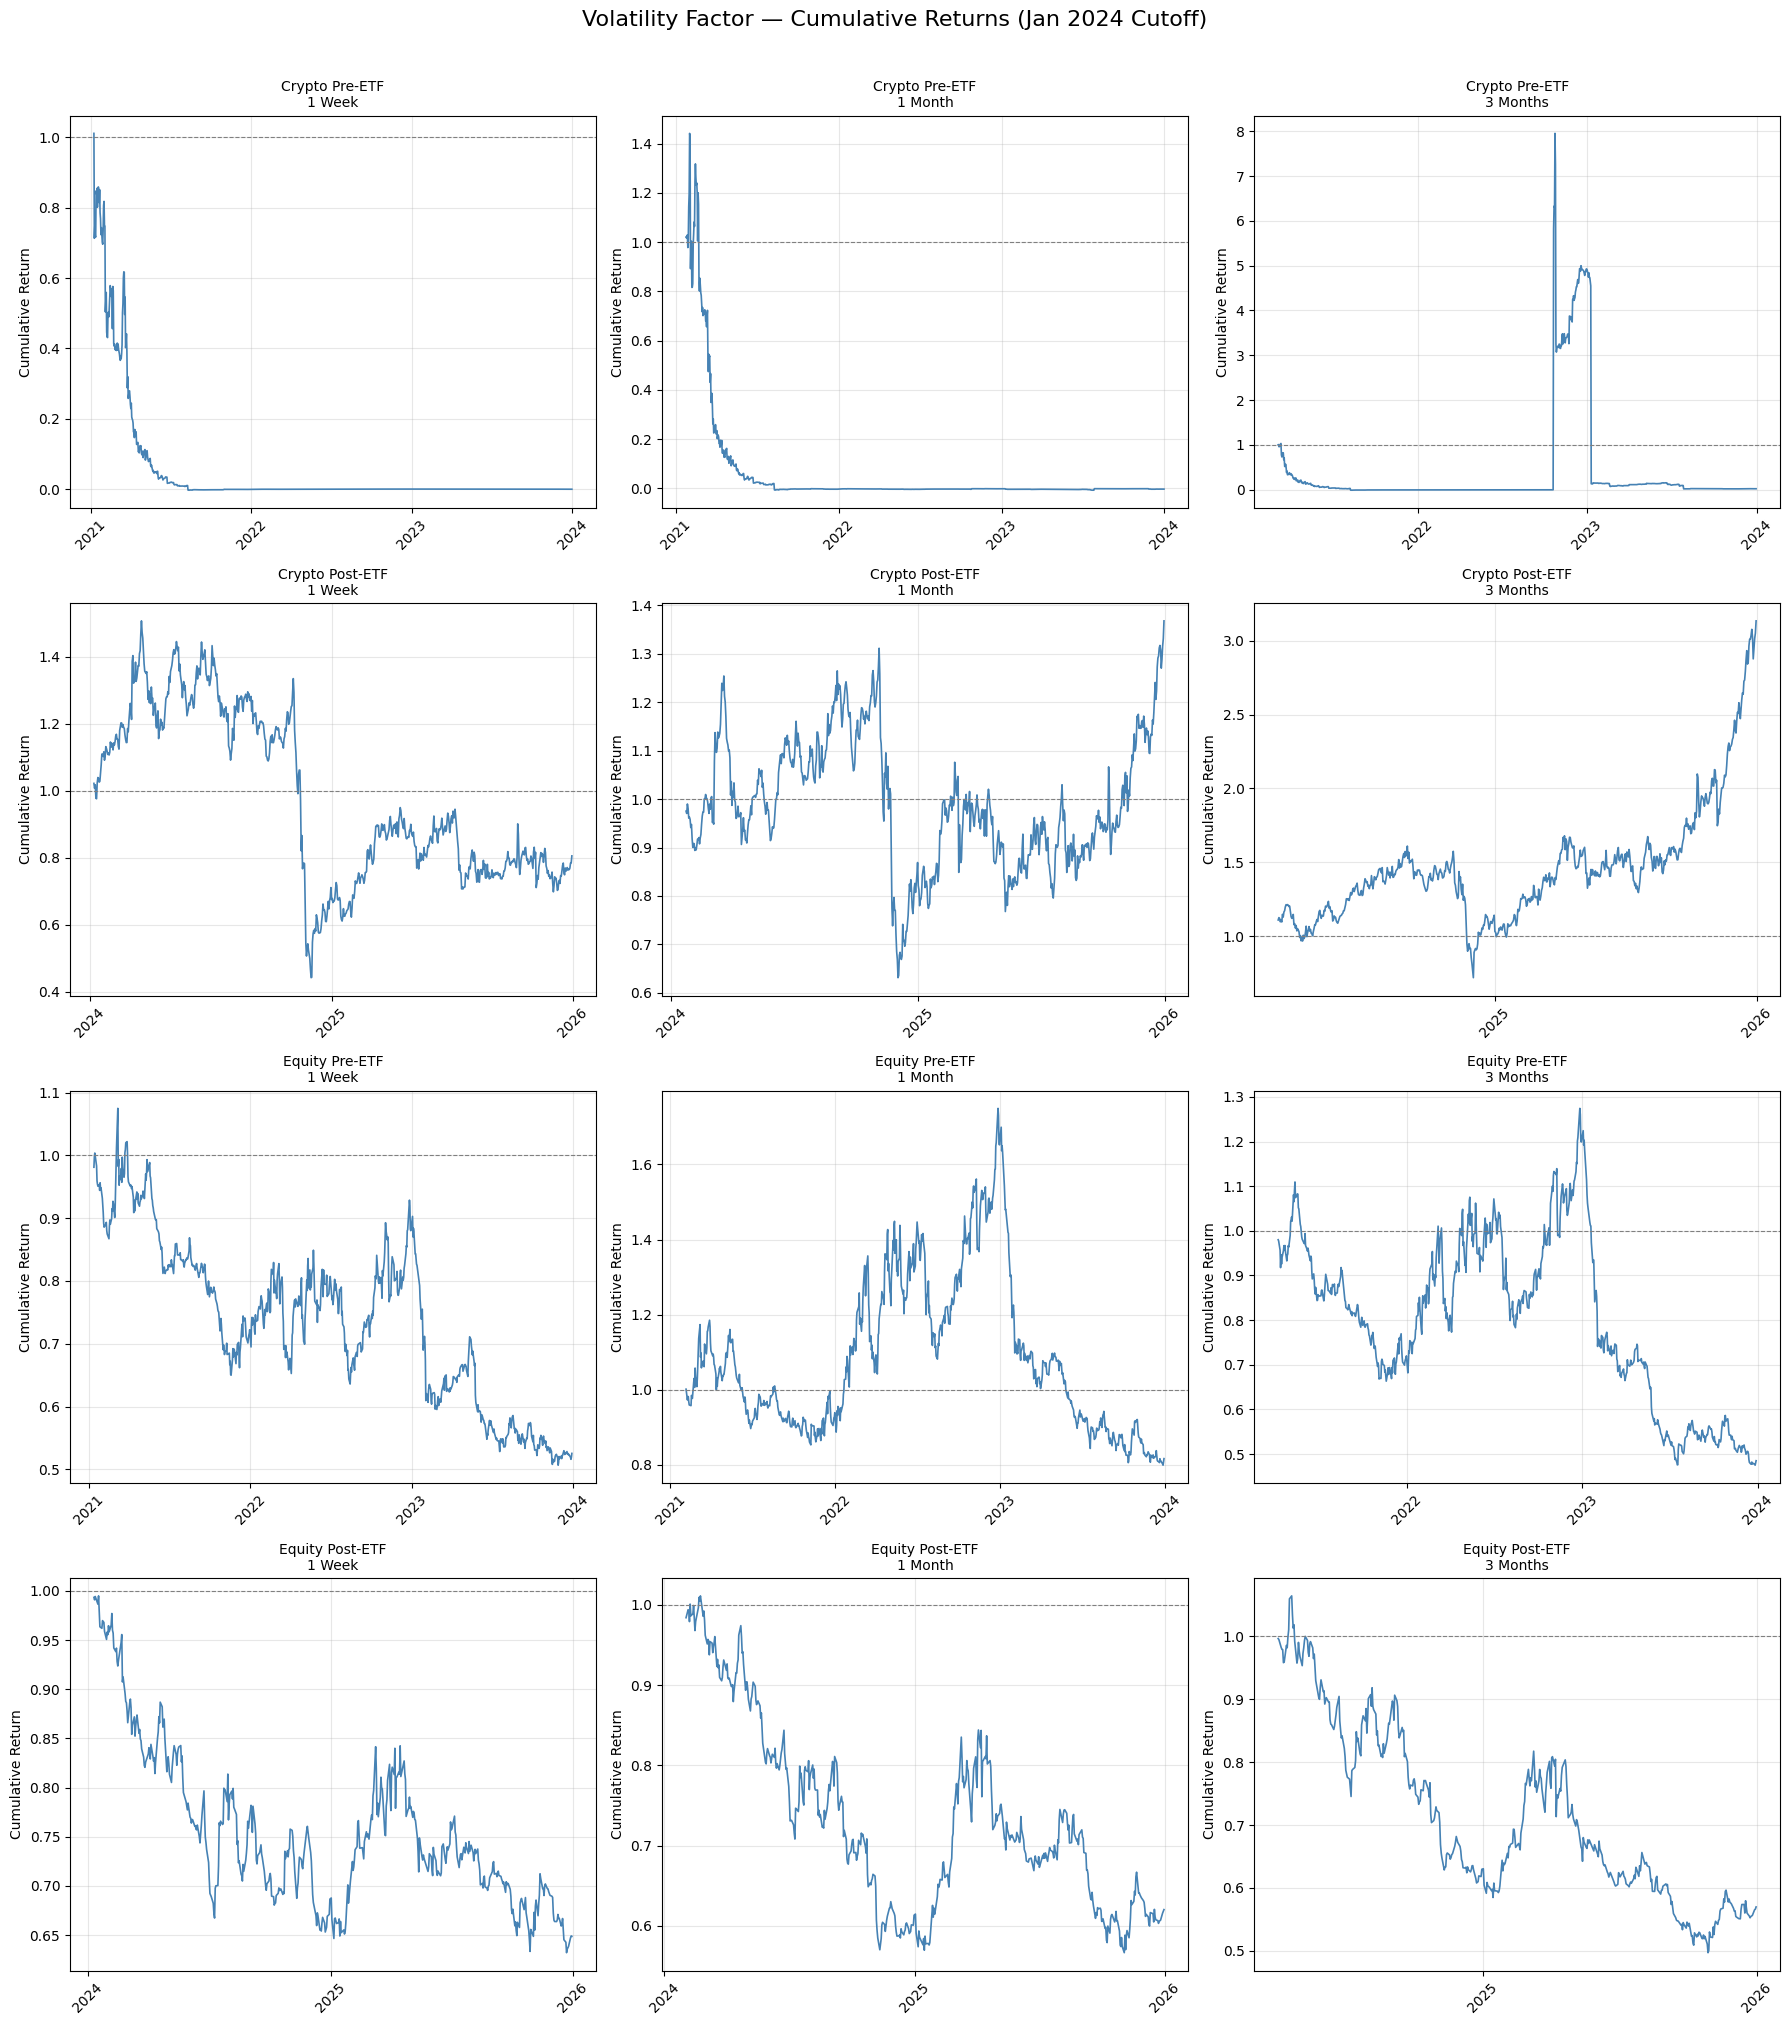

Saved vol_cumulative_jan2024.png

── Volatility Sharpe Summary (Jan 2024 Cutoff) ──
        Dataset   Window  Vol Sharpe
 Crypto Pre-ETF   1 Week      -0.876
 Crypto Pre-ETF  1 Month      -0.307
 Crypto Pre-ETF 3 Months      -0.495
Crypto Post-ETF   1 Week       0.073
Crypto Post-ETF  1 Month       0.475
Crypto Post-ETF 3 Months       1.139
 Equity Pre-ETF   1 Week      -0.514
 Equity Pre-ETF  1 Month      -0.018
 Equity Pre-ETF 3 Months      -0.513
Equity Post-ETF   1 Week      -0.667
Equity Post-ETF  1 Month      -0.638
Equity Post-ETF 3 Months      -0.834
Saved vol_sharpe_jan2024.xlsx

====== ANNOUNCEMENT ADJUSTED (Jun 2023 cutoff) ======

Crypto Pre-ETF | 1 Week | Vol Sharpe: -1.033
Crypto Pre-ETF | 1 Month | Vol Sharpe: -0.515
Crypto Pre-ETF | 3 Months | Vol Sharpe: -0.551
Crypto Post-ETF | 1 Week | Vol Sharpe: 0.273
Crypto Post-ETF | 1 Month | Vol Sharpe: 0.55
Crypto Post-ETF | 3 Months | Vol Sharpe: 0.815
Equity Pre-ETF | 1 Week | Vol Sharpe: -0.502
Equity Pre-ETF | 1 Month | Vo

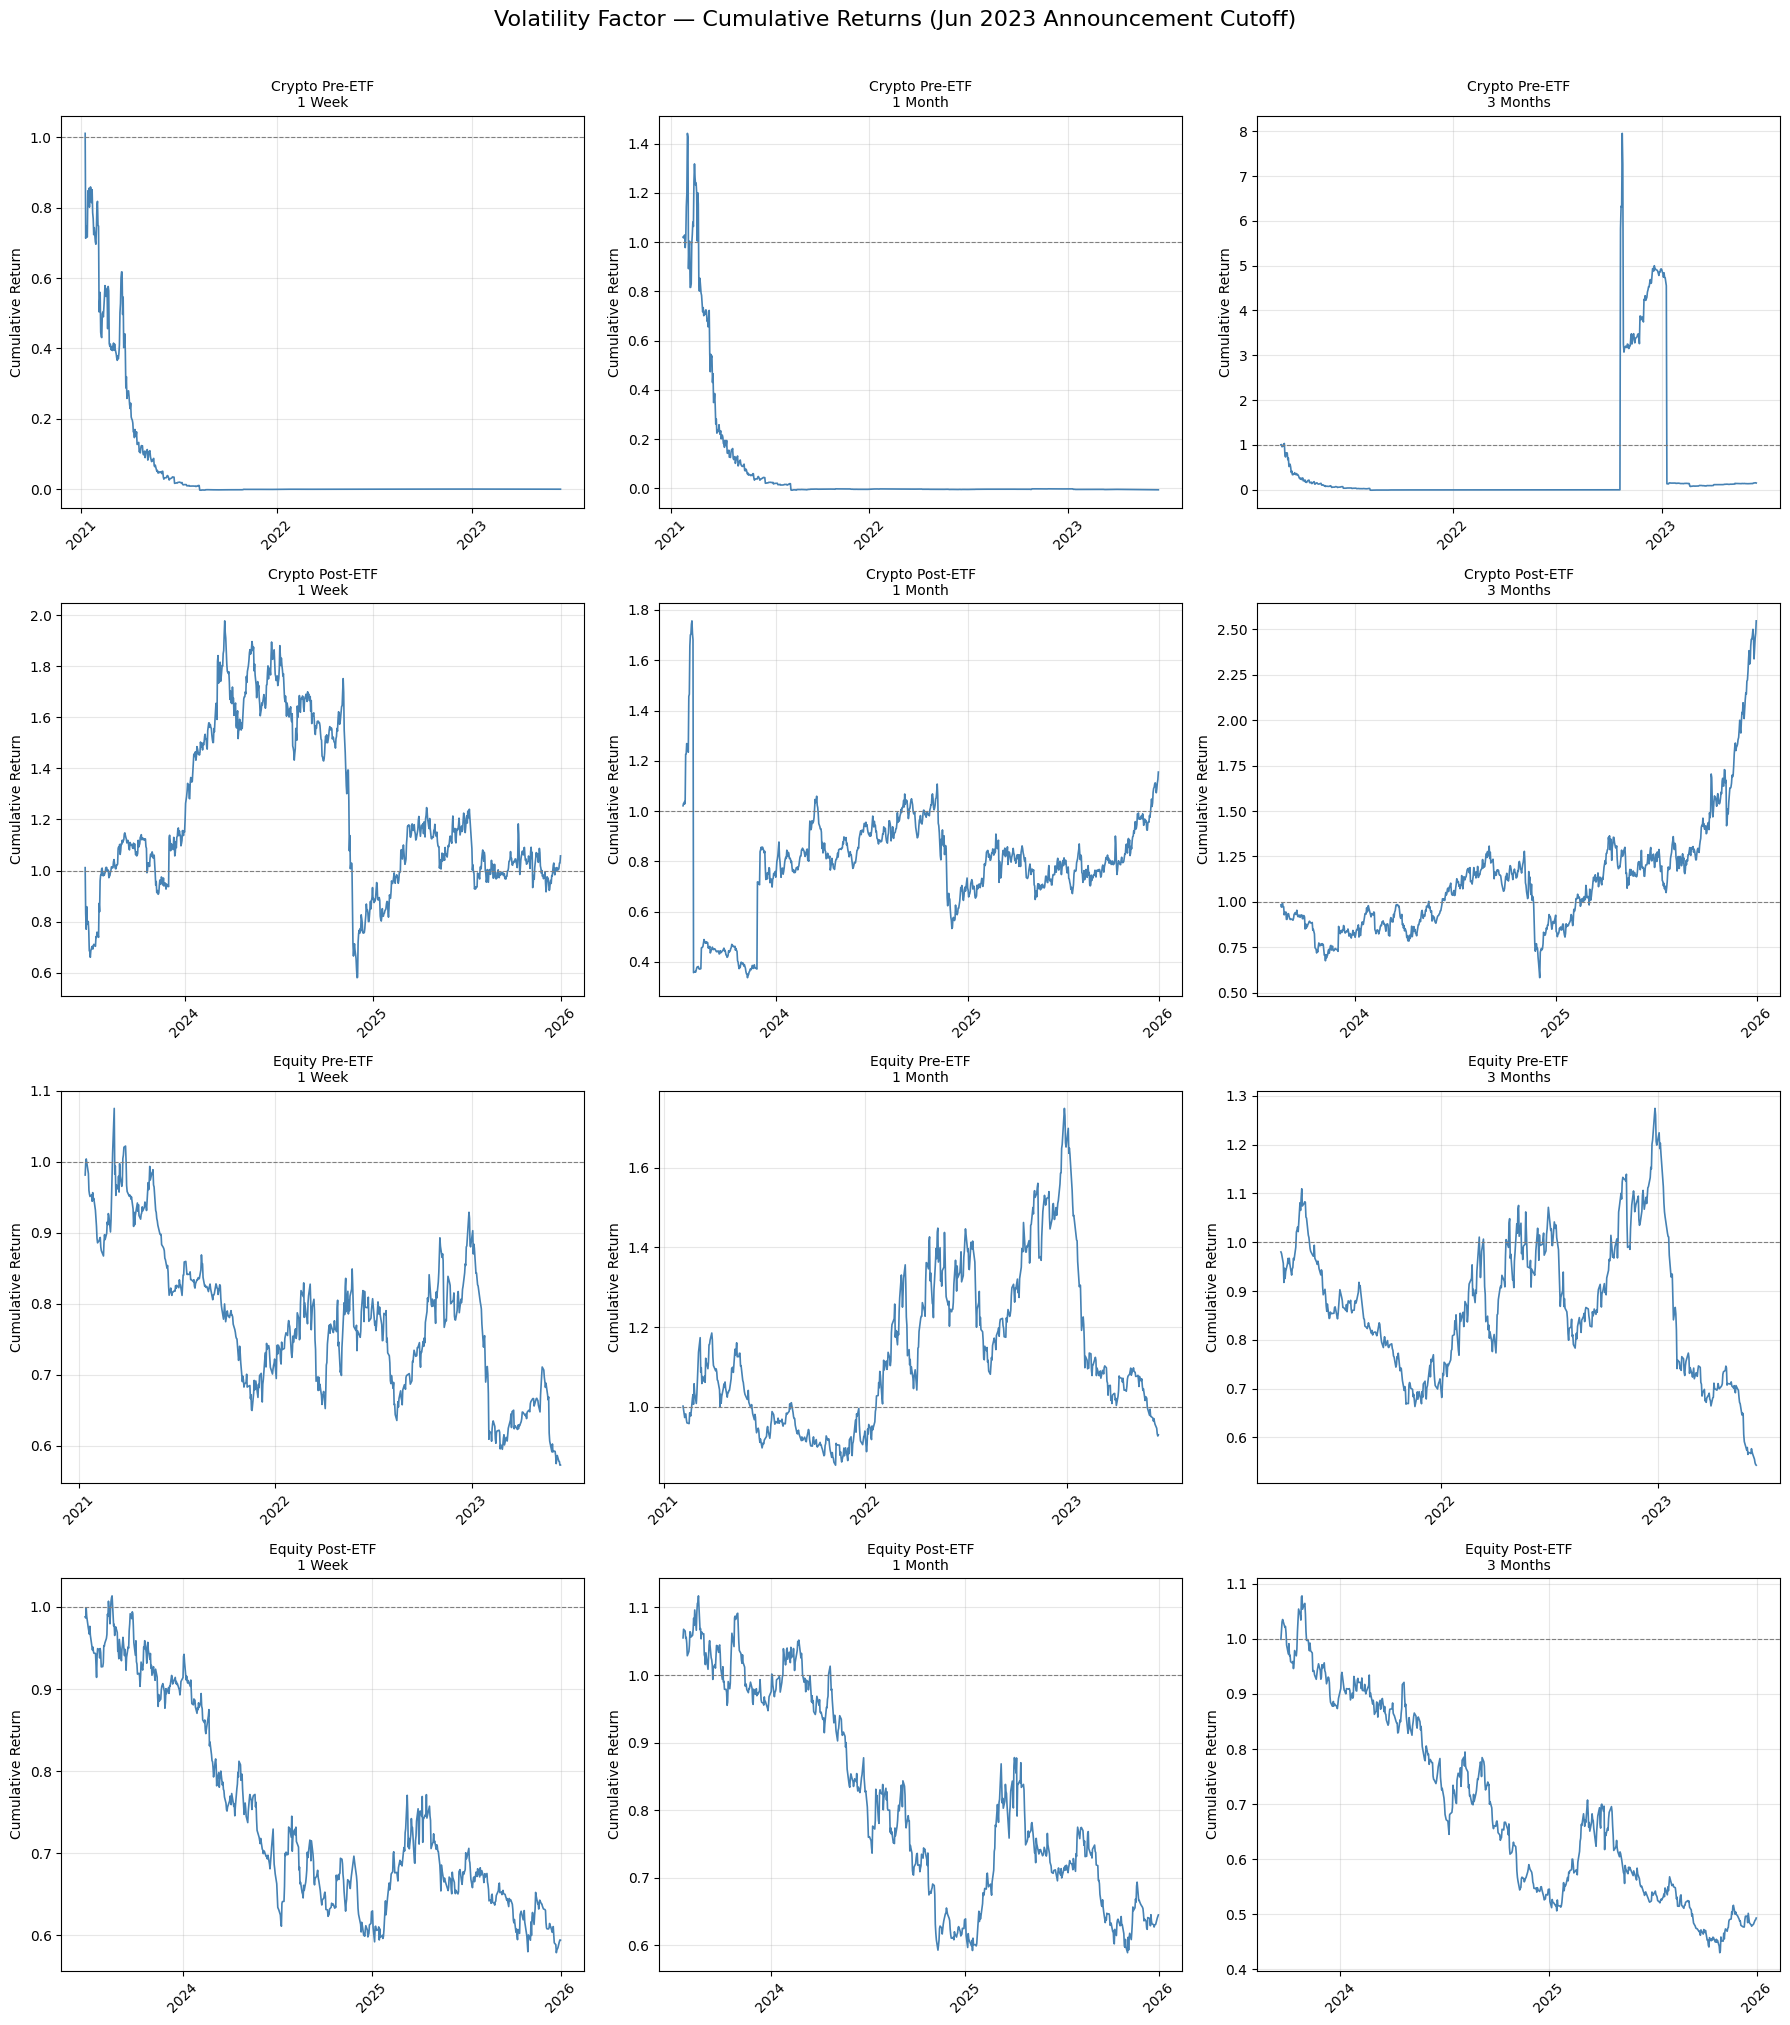

Saved vol_cumulative_jun2023_announcement.png

── Volatility Sharpe Summary (Jun 2023 Announcement Cutoff) ──
        Dataset   Window  Vol Sharpe
 Crypto Pre-ETF   1 Week      -1.033
 Crypto Pre-ETF  1 Month      -0.515
 Crypto Pre-ETF 3 Months      -0.551
Crypto Post-ETF   1 Week       0.273
Crypto Post-ETF  1 Month       0.550
Crypto Post-ETF 3 Months       0.815
 Equity Pre-ETF   1 Week      -0.502
 Equity Pre-ETF  1 Month       0.107
 Equity Pre-ETF 3 Months      -0.497
Equity Post-ETF   1 Week      -0.666
Equity Post-ETF  1 Month      -0.449
Equity Post-ETF 3 Months      -0.861
Saved vol_sharpe_jun2023_announcement.xlsx


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── load both datasets ────────────────────────────────────────────────────

# Original split (Jan 2024 cutoff)
crypto_returns_pre_orig  = pd.read_excel("returns_data.xlsx", sheet_name="Crypto Pre ETF",  index_col="Date", parse_dates=True)
crypto_returns_post_orig = pd.read_excel("returns_data.xlsx", sheet_name="Crypto Post ETF", index_col="Date", parse_dates=True)
equity_returns_pre_orig  = pd.read_excel("returns_data.xlsx", sheet_name="Equity Pre ETF",  index_col="Date", parse_dates=True)
equity_returns_post_orig = pd.read_excel("returns_data.xlsx", sheet_name="Equity Post ETF", index_col="Date", parse_dates=True)

# Announcement adjusted split (Jun 2023 cutoff)
crypto_returns_pre_adj  = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Crypto Pre ETF",  index_col="Date", parse_dates=True)
crypto_returns_post_adj = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Crypto Post ETF", index_col="Date", parse_dates=True)
equity_returns_pre_adj  = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Equity Pre ETF",  index_col="Date", parse_dates=True)
equity_returns_post_adj = pd.read_excel("returns_annoucement_adj.xlsx", sheet_name="Equity Post ETF", index_col="Date", parse_dates=True)

# ── lookback windows ──────────────────────────────────────────────────────
windows = {
    "1 Week":   5,
    "1 Month":  21,
    "3 Months": 63
}

# ── helper: volatility factor ─────────────────────────────────────────────
def volatility_factor(returns_df, lookback, top_pct=0.2):
    """
    Each day:
      1. Compute realized volatility over lookback window for each asset
      2. Rank assets — long low vol (bottom 20%), short high vol (top 20%)
      3. Record equal-weighted portfolio return next day
    """
    n = len(returns_df.columns)
    n_assets = max(1, int(n * top_pct))
    portfolio_returns = []

    for i in range(lookback, len(returns_df) - 1):
        # realized vol = std of returns over lookback window
        vol = returns_df.iloc[i - lookback:i].std()

        ranked = vol.rank()
        long_assets  = ranked.nsmallest(n_assets).index  # long LOW vol
        short_assets = ranked.nlargest(n_assets).index   # short HIGH vol

        next_day = returns_df.iloc[i + 1]
        port_return = next_day[long_assets].mean() - next_day[short_assets].mean()
        portfolio_returns.append({
            "Date": returns_df.index[i + 1],
            "Return": port_return
        })

    result = pd.DataFrame(portfolio_returns).set_index("Date")
    result["Cumulative"] = (1 + result["Return"]).cumprod()
    return result

# ── helper: Sharpe ratio ──────────────────────────────────────────────────
def sharpe(returns_series, periods_per_year=252):
    mean = returns_series.mean() * periods_per_year
    std  = returns_series.std() * np.sqrt(periods_per_year)
    return round(mean / std, 3) if std != 0 else np.nan

# ── helper: run and plot one full dataset ─────────────────────────────────
def run_vol_analysis(datasets, label_suffix, plot_filename, sharpe_filename):

    vol_results = {}

    for label, df in datasets.items():
        vol_results[label] = {}
        for wname, wdays in windows.items():
            vol_results[label][wname] = volatility_factor(df, wdays)
            print(f"{label} | {wname} | "
                  f"Vol Sharpe: {sharpe(vol_results[label][wname]['Return'])}")

    # Plot
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    fig.suptitle(f"Volatility Factor — Cumulative Returns ({label_suffix})",
                 fontsize=16, y=1.01)

    for row_idx, (label, window_dict) in enumerate(vol_results.items()):
        for col_idx, (wname, result) in enumerate(window_dict.items()):
            ax = axes[row_idx][col_idx]
            ax.plot(result.index, result["Cumulative"], linewidth=1.2, color="steelblue")
            ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
            ax.set_title(f"{label}\n{wname}", fontsize=10)
            ax.set_ylabel("Cumulative Return")
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.tick_params(axis="x", rotation=45)
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(plot_filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {plot_filename}")

    # Sharpe summary
    sharpe_rows = []
    for label in datasets.keys():
        for wname in windows.keys():
            sharpe_rows.append({
                "Dataset":     label,
                "Window":      wname,
                "Vol Sharpe":  sharpe(vol_results[label][wname]["Return"])
            })

    sharpe_df = pd.DataFrame(sharpe_rows)
    print(f"\n── Volatility Sharpe Summary ({label_suffix}) ──")
    print(sharpe_df.to_string(index=False))

    sharpe_df.to_excel(sharpe_filename, index=False)
    print(f"Saved {sharpe_filename}")

    return vol_results

# ── run original split (Jan 2024 cutoff) ─────────────────────────────────
print("\n====== ORIGINAL SPLIT (Jan 2024 cutoff) ======\n")
datasets_orig = {
    "Crypto Pre-ETF":  crypto_returns_pre_orig,
    "Crypto Post-ETF": crypto_returns_post_orig,
    "Equity Pre-ETF":  equity_returns_pre_orig,
    "Equity Post-ETF": equity_returns_post_orig
}

vol_results_orig = run_vol_analysis(
    datasets_orig,
    label_suffix    = "Jan 2024 Cutoff",
    plot_filename   = "vol_cumulative_jan2024.png",
    sharpe_filename = "vol_sharpe_jan2024.xlsx"
)

# ── run announcement adjusted split (Jun 2023 cutoff) ────────────────────
print("\n====== ANNOUNCEMENT ADJUSTED (Jun 2023 cutoff) ======\n")
datasets_adj = {
    "Crypto Pre-ETF":  crypto_returns_pre_adj,
    "Crypto Post-ETF": crypto_returns_post_adj,
    "Equity Pre-ETF":  equity_returns_pre_adj,
    "Equity Post-ETF": equity_returns_post_adj
}

vol_results_adj = run_vol_analysis(
    datasets_adj,
    label_suffix    = "Jun 2023 Announcement Cutoff",
    plot_filename   = "vol_cumulative_jun2023_announcement.png",
    sharpe_filename = "vol_sharpe_jun2023_announcement.xlsx"
)